# Formula 1 Scheduling Trends — Exploratory Data Analysis

**Research Question:** Can historical Formula 1 race data be used to identify scheduling trends and predict future season calendars or popular circuit selections?

**Data Source:** [Kaggle — Formula 1 World Championship (1950–2024)](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020). This notebook uses `races.csv`, `circuits.csv`, and `seasons.csv`.

**Why this matters:** Formula 1 is a billion-dollar global business. Every race weekend triggers a chain reaction — hotels book up, flights surge in price, city infrastructure gets stretched, and broadcast contracts get locked in months in advance. Understanding how the calendar has evolved helps organizers, sponsors, and host cities plan with data instead of guesswork.

This notebook covers:
1. Data loading and cleaning
2. How the size of the calendar has changed over time
3. How the geographic footprint of F1 has shifted (regional trends)
4. Which circuits have been the backbone of the calendar
5. Summary of findings that feed into the modeling notebook (`02_modeling.ipynb`)


In [1]:
import pandas as pd
import numpy as np                      # used below for rate-of-change / summary stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")        # cleaner default look for all plots in this notebook
pd.set_option('display.max_columns', None)

DATA_DIR = "../data"


## 1. Load the data

In [2]:
# Load the three tables relevant to a scheduling question.
# (The full Kaggle download also has lap times / pit stops / results, but those
# describe race performance, not the calendar itself, so we don't need them here.)
races = pd.read_csv(f"{DATA_DIR}/races.csv")
circuits = pd.read_csv(f"{DATA_DIR}/circuits.csv")
seasons = pd.read_csv(f"{DATA_DIR}/seasons.csv")

print(f"races: {races.shape[0]:,} rows, {races.shape[1]} columns")
print(f"circuits: {circuits.shape[0]:,} rows, {circuits.shape[1]} columns")
print(f"seasons: {seasons.shape[0]:,} rows, {seasons.shape[1]} columns")
print(f"Season range: {races['year'].min()} - {races['year'].max()}")
races.head(3)


races: 1,125 rows, 18 columns
circuits: 77 rows, 9 columns
seasons: 75 rows, 2 columns
Season range: 1950 - 2024


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


## 2. Data cleaning

Two issues surfaced during inspection:

- `circuits.country` uses **both** `"USA"` and `"United States"` for the same country — these need to be unified before any country-level aggregation.
- Several timing columns (`fp1_time`, `sprint_date`, etc.) use the literal string `"\\N"` for missing values rather than a true null. We don't need those columns for scheduling analysis, so we drop them rather than trying to fix every one.


In [3]:
# Unify country naming
circuits['country'] = circuits['country'].replace({'United States': 'USA'})

# Keep only the columns relevant to scheduling analysis
races_slim = races[['raceId', 'year', 'round', 'circuitId', 'name', 'date']].copy()
races_slim['date'] = pd.to_datetime(races_slim['date'], errors='coerce')

# Confirm no missing values remain in the columns we actually use
print("Missing values in key columns:")
print(races_slim.isnull().sum())


Missing values in key columns:
raceId       0
year         0
round        0
circuitId    0
name         0
date         0
dtype: int64


### Mapping countries to continents

The rubric question asks about *regional* shifts, so we add a continent label. This mapping is built by hand from the 35 countries present in the dataset (there's no continent column in the raw data).


In [4]:
continent_map = {
    'Australia': 'Oceania', 'Malaysia': 'Asia', 'Bahrain': 'Asia', 'Spain': 'Europe',
    'Turkey': 'Asia', 'Monaco': 'Europe', 'Canada': 'North America', 'France': 'Europe',
    'UK': 'Europe', 'Germany': 'Europe', 'Hungary': 'Europe', 'Belgium': 'Europe',
    'Italy': 'Europe', 'Singapore': 'Asia', 'Japan': 'Asia', 'China': 'Asia',
    'Brazil': 'South America', 'USA': 'North America', 'Mexico': 'North America',
    'Azerbaijan': 'Asia', 'Russia': 'Europe', 'Austria': 'Europe', 'Netherlands': 'Europe',
    'Portugal': 'Europe', 'South Africa': 'Africa', 'Argentina': 'South America',
    'Sweden': 'Europe', 'Switzerland': 'Europe', 'India': 'Asia', 'Korea': 'Asia',
    'Qatar': 'Asia', 'Saudi Arabia': 'Asia', 'UAE': 'Asia', 'Morocco': 'Africa'
}
circuits['continent'] = circuits['country'].map(continent_map)

# Fail loudly rather than silently if a country slips through unmapped -
# a silent NaN here would quietly break every regional aggregation below.
assert circuits['continent'].isnull().sum() == 0, "Unmapped country found"

# One row per race, enriched with where that race happened
df = races_slim.merge(
    circuits[['circuitId', 'name', 'country', 'continent', 'lat', 'lng']],
    on='circuitId', suffixes=('_race', '_circuit')
)
df['decade'] = (df['year'] // 10) * 10   # bucket seasons into decades for the trend charts below
print(f"Merged dataset: {df.shape[0]:,} race rows")
df.head(3)


Merged dataset: 1,125 race rows


,raceId,year,round,circuitId,name_race,date,name_circuit,country,continent,lat,lng,decade
0,1,2009,1,1,Australian Grand Prix,2009-03-29,Albert Park Grand Prix Circuit,Australia,Oceania,-37.84970,144.968,2000
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,Sepang International Circuit,Malaysia,Asia,2.76083,101.738,2000
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,Shanghai International Circuit,China,Asia,31.33890,121.220,2000


## 3. How has the size of the calendar changed?

The most direct scheduling signal is simply *how many races happen each season*.


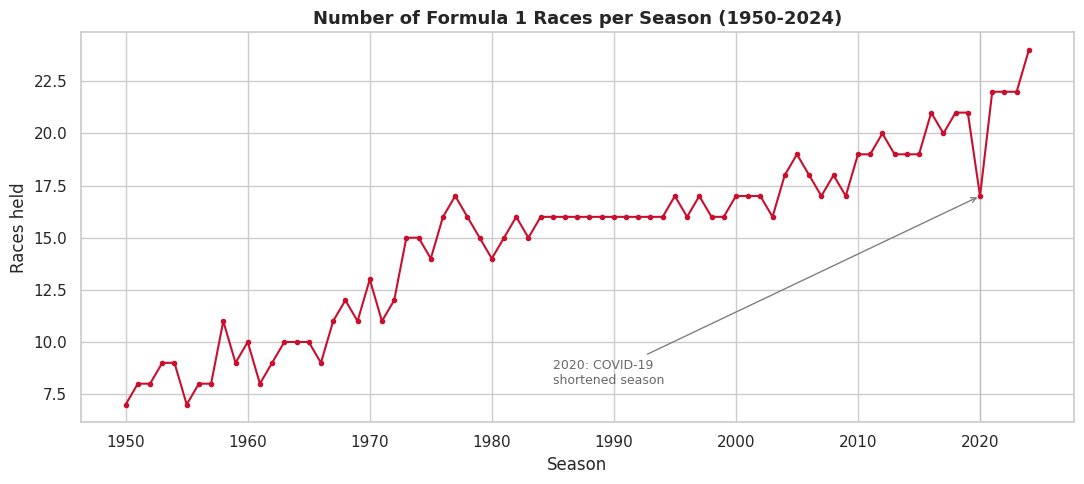

Average races per season by decade:
decade
1950     8.4
1960    10.0
1970    14.4
1980    15.6
1990    16.2
2000    17.4
2010    19.8
2020    21.4
dtype: float64


In [5]:
races_per_year = races_slim.groupby('year').size()

# Single continuous line is the right chart for one continuous variable (race count) over time
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(races_per_year.index, races_per_year.values, marker='o', markersize=3, linewidth=1.5, color='#C8102E')
ax.set_title('Number of Formula 1 Races per Season (1950-2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Races held')
ax.axvspan(2020, 2020, color='grey', alpha=0.2)          # shade the pandemic season so it reads as an outlier, not noise
ax.annotate('2020: COVID-19\nshortened season', xy=(2020, 17), xytext=(1985, 8),
            arrowprops=dict(arrowstyle='->', color='grey'), fontsize=9, color='dimgrey')
plt.tight_layout()
plt.show()

# Decade-level averages smooth out year-to-year noise (like the 2020 dip) so the
# underlying growth trend is easier to read than from the raw yearly numbers above
decade_of = (races_slim['year'] // 10) * 10
avg_by_decade = races_slim.assign(decade=decade_of).groupby('decade').size().div(
    races_slim.assign(decade=decade_of).groupby('decade')['year'].nunique()
)
print("Average races per season by decade:")
print(np.round(avg_by_decade, 1))


**Finding:** The calendar has grown almost every decade — from roughly 7-8 races a season in the 1950s to over 20 a season in the 2020s (2020 is a clear pandemic-driven outlier, not a trend reversal). This steady growth is the core signal the forecasting model in the modeling notebook will try to extrapolate.

## 4. Where has the calendar been growing? (Regional shift)

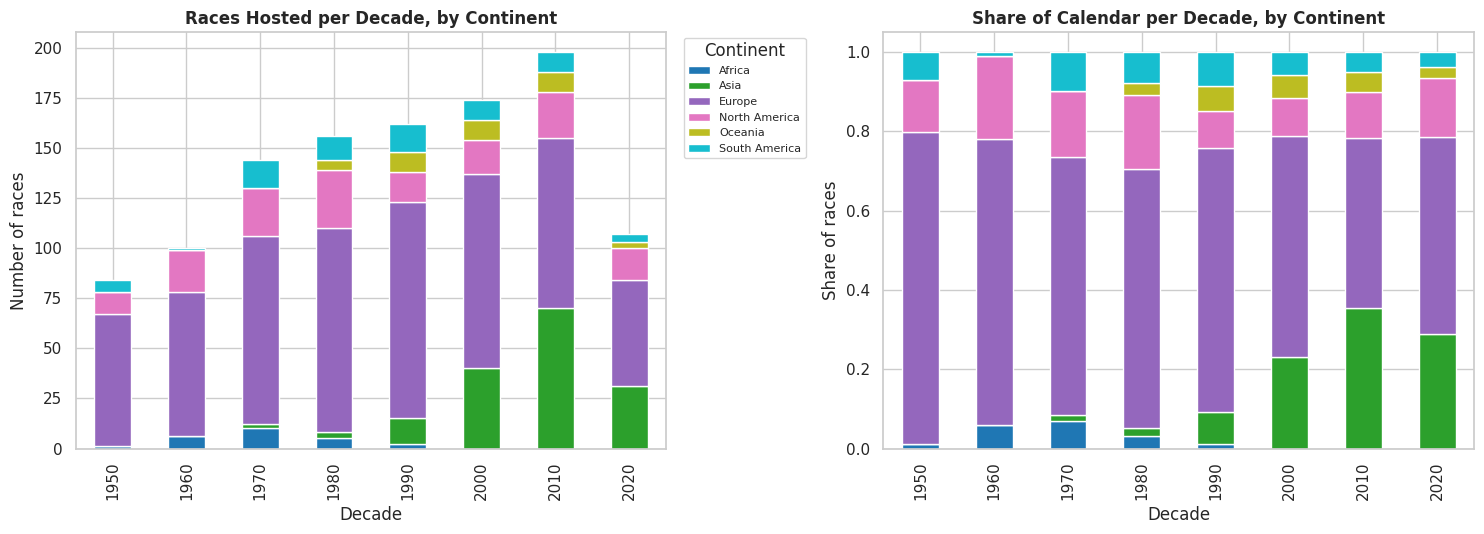

In [6]:
# Counts by decade x continent (categorical x categorical -> pivot table)
region_decade = df.groupby(['decade', 'continent']).size().unstack(fill_value=0)
# Same table, normalized to a 0-1 share per decade - needed to see the *share* shift,
# since raw counts alone can't distinguish "Europe shrank" from "everyone else grew"
region_decade_share = region_decade.div(region_decade.sum(axis=1), axis=0)

# Two subplots side by side: absolute counts vs. share, so both stories are visible at once
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

region_decade.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10')
axes[0].set_title('Races Hosted per Decade, by Continent', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Number of races')
axes[0].legend(title='Continent', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

region_decade_share.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', legend=False)
axes[1].set_title('Share of Calendar per Decade, by Continent', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Share of races')

plt.tight_layout()
plt.show()


**Finding:** Europe dominated the calendar for F1's first 50 years, but its *share* has fallen steadily since the 1990s as Asia (Bahrain, China, Singapore, Malaysia, Azerbaijan, Saudi Arabia, Qatar) and, more recently, the Middle East have entered the calendar. This is the "regional shift" the research question anticipated — it isn't that Europe disappeared, it's that growth is happening almost entirely outside it.

## 5. Which circuits are the backbone of the calendar?

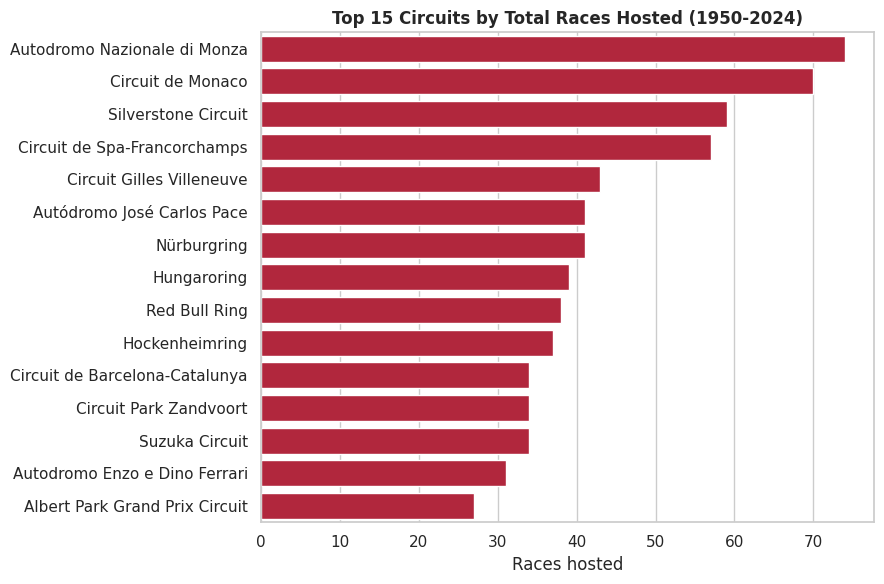

In [7]:
# Total races hosted per circuit, top 15 -> a categorical variable (circuit name),
# so a horizontal bar chart (not a line) is the appropriate plot here
top_circuits = df.groupby('name_circuit').size().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_circuits.values, y=top_circuits.index, ax=ax, color='#C8102E')
ax.set_title('Top 15 Circuits by Total Races Hosted (1950-2024)', fontsize=12, fontweight='bold')
ax.set_xlabel('Races hosted')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [8]:
# One row per circuit summarizing its full history on the calendar
circuit_span = df.groupby('name_circuit').agg(
    total_races=('raceId', 'count'),
    first_year=('year', 'min'),
    last_year=('year', 'max')
)
circuit_span['active_span_years'] = circuit_span['last_year'] - circuit_span['first_year'] + 1
circuit_span['still_active'] = circuit_span['last_year'] >= 2023   # 2023/2024 treated as "current"

print(f"Circuits used at least once: {circuit_span.shape[0]}")
print(f"Circuits used only once: {(circuit_span['total_races']==1).sum()}")
print(f"Circuits active for 40+ years: {(circuit_span['active_span_years']>=40).sum()}")
circuit_span.sort_values('total_races', ascending=False).head(10)


Circuits used at least once: 77
Circuits used only once: 11
Circuits active for 40+ years: 15


,total_races,first_year,last_year,active_span_years,still_active
name_circuit,,,,,
Autodromo Nazionale di Monza,74,1950,2024,75,True
Circuit de Monaco,70,1950,2024,75,True
Silverstone Circuit,59,1950,2024,75,True
Circuit de Spa-Francorchamps,57,1950,2024,75,True
Circuit Gilles Villeneuve,43,1978,2024,47,True
Autódromo José Carlos Pace,41,1973,2024,52,True
Nürburgring,41,1951,2020,70,False
Hungaroring,39,1986,2024,39,True
Red Bull Ring,38,1970,2024,55,True


**Finding:** A small set of circuits (Monza, Monaco, Silverstone, Spa-Francorchamps) have anchored the calendar for over 70 years, while a long tail of circuits — often in newer markets — have appeared once or twice. This "core vs. rotating" structure is the pattern the circuit-retention classifier in the modeling notebook tries to formalize.

## 6. How many distinct countries/continents does F1 visit each season?

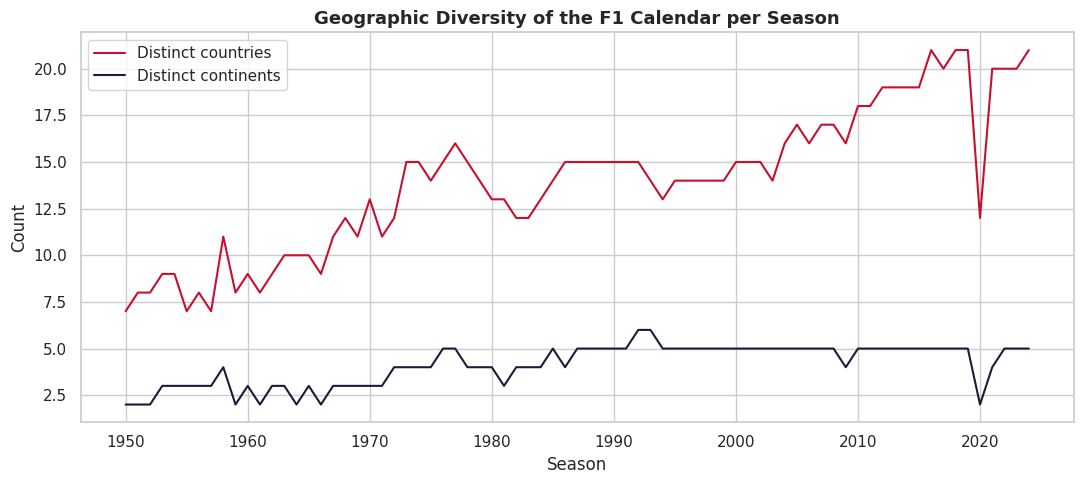

In [9]:
# Unique countries/continents visited per season - two continuous variables over time
diversity = df.groupby('year').agg(
    num_countries=('country', 'nunique'),
    num_continents=('continent', 'nunique')
)

# Two lines on one set of axes (rather than two separate subplots) since both
# series share the same x-axis (season) and a comparable small-number scale
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(diversity.index, diversity['num_countries'], label='Distinct countries', color='#C8102E')
ax.plot(diversity.index, diversity['num_continents'], label='Distinct continents', color='#1B1B3A')
ax.set_title('Geographic Diversity of the F1 Calendar per Season', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()


**Finding:** F1 didn't just add more races — it visibly globalized. The calendar now touches nearly every inhabited continent every season, up from typically 1-2 continents through the 1980s.

## 7. Summary of EDA findings

1. **Growth:** Season length has grown almost every decade, from ~7-8 races in the 1950s to 22-24 in the 2020s. 2020 is a one-off pandemic dip, not a trend break.
2. **Regional shift:** Europe's *share* of the calendar has fallen from near-100% before 1990 to roughly half today, entirely because of growth in Asia and the Middle East — Europe's absolute race count hasn't collapsed, it's just no longer where the growth happens.
3. **Core vs. rotating circuits:** A handful of historic European circuits have hosted races almost every year for 70+ years, while a much larger group of circuits (often newer markets) have appeared for only a season or two.
4. **Globalization:** The number of distinct countries and continents visited per season has climbed steadily, reflecting F1's expansion strategy.

These findings motivate the three modeling questions tackled in `02_modeling.ipynb`:
- **Regression / time series:** forecast how many races next season's calendar will likely contain.
- **Classification:** predict whether a given circuit, once on the calendar, is likely to be retained the following season.
- **Clustering:** group circuits into natural "tiers" (legacy anchors, modern additions, one-off try-outs) without using pre-set labels.
